# S&P 500 Sector Performance: Exploratory Data Analysis

This notebook explores historical price data for the 11 SPDR sector EFTs that make up the S&P 500. The goal is for me to understand how each sector behaves across different market environments before building a PowerBI dashboard.

**Sectors Covered:** XLB (Materials), XLC (Communication Services), XLE (Energy), XLF (Finance), XLI (Industrials), XLK (Technology), XLP (Consumer Staples), XLRE (Real Estate), XLU (Utilities), XLV (Health Care), XLY (Consumer Discretionary)

**Date Range:** June 2018 - March 2026

**Data Source:** Yahoo Finance via `yfinance`


## Setup
Import libraries and configure plot styling.

In [70]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np

sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 15
plt.rcParams["xtick.labelsize"] = 12
plt.rcParams["ytick.labelsize"] = 12

# Sector names
SECTOR_NAMES = {
    "XLB":  "Materials",
    "XLC":  "Communication",
    "XLE":  "Energy",
    "XLF":  "Financials",
    "XLI":  "Industrials",
    "XLK":  "Technology",
    "XLP":  "Consumer Staples",
    "XLRE": "Real Estate",
    "XLU":  "Utilities",
    "XLV":  "Health Care",
    "XLY":  "Consumer Discr.",
}

## Load Data

Read the cleaned combined CSV. Data is in long format: one row per trading day per sector, two columns (`price` and `ticker`). Pivot to wide fromat for plotting.

In [79]:
df = pd.read_csv(
    "../data/cleaned/all_sectors_combined.csv",
    parse_dates=["date"],
    index_col="date"
)

print(f"Shape:      {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Date range: {df.index.min().date()} to {df.index.max().date()}")
print(f"Sectors:    {df['ticker'].nunique()}")
print("\nRow counts per sector:")
print(df["ticker"].value_counts().to_string())
print("\nSample:")
df.head()

Shape:      22,676 rows x 2 columns
Date range: 2018-01-02 to 2026-03-31
Sectors:    11

Row counts per sector:
ticker
XLK     2072
XLF     2072
XLE     2072
XLV     2072
XLY     2072
XLP     2072
XLI     2072
XLB     2072
XLU     2072
XLRE    2072
XLC     1956

Sample:


,price,ticker
date,,
2018-01-02,29.872925,XLK
2018-01-03,30.122091,XLK
2018-01-04,30.274368,XLK
2018-01-05,30.592749,XLK
2018-01-08,30.708113,XLK


## Reshape and Validate

Pivot from long to wide format. One column per sector, date as the index. XLC launched in June 2018 so it has 116 fewer rows than the others. Thus, we need to trim the dataset to the first date where all sectors have data.

In [80]:
# Check for nulls and pivot to wide format
prices = df.pivot(columns="ticker", values="price")

print(f"Shape: {prices.shape}")
print(f"Any nulls: {prices.isnull().sum().sum()}")
prices.head()

Shape: (2072, 11)
Any nulls: 116


ticker,XLB,XLC,XLE,XLF,XLI,XLK,XLP,XLRE,XLU,XLV,XLY
date,,,,,,,,,,,
2018-01-02,25.995678,NaN,25.747263,23.884138,66.254852,29.872925,45.314564,24.837584,20.132582,72.723351,46.275234
2018-01-03,26.177761,NaN,26.132860,24.012457,66.611702,30.122091,45.298542,24.845167,19.974417,73.419151,46.487701
2018-01-04,26.406424,NaN,26.290604,24.234871,67.099144,30.274368,45.426765,24.420460,19.808542,73.523552,46.640110
2018-01-05,26.618156,NaN,26.280090,24.303312,67.560448,30.592749,45.627129,24.473557,19.800835,74.149796,47.009609
2018-01-08,26.656261,NaN,26.437834,24.269096,67.838974,30.708113,45.739338,24.640398,19.985998,73.880157,47.065033


In [81]:
null_counts = prices.isnull().sum()
print("Nulls per sector:")
print(null_counts[null_counts > 0])

null_dates = prices[prices.isnull().any(axis=1)]
print(f"Rows with at least one null: {len(null_dates)}")
print(null_dates)

Nulls per sector:
ticker
XLC    116
dtype: int64
Rows with at least one null: 116
ticker            XLB  XLC        XLE        XLF        XLI        XLK  \
date                                                                     
2018-01-02  25.995678  NaN  25.747263  23.884138  66.254852  29.872925   
2018-01-03  26.177761  NaN  26.132860  24.012457  66.611702  30.122091   
2018-01-04  26.406424  NaN  26.290604  24.234871  67.099144  30.274368   
2018-01-05  26.618156  NaN  26.280090  24.303312  67.560448  30.592749   
2018-01-08  26.656261  NaN  26.437834  24.269096  67.838974  30.708113   
...               ...  ...        ...        ...        ...        ...   
2018-06-12  25.929220  NaN  27.081476  23.996838  66.862679  33.377754   
2018-06-13  25.648676  NaN  26.979103  23.910975  66.329620  33.206497   
2018-06-14  25.686930  NaN  26.940268  23.687756  66.076164  33.442554   
2018-06-15  25.507565  NaN  26.361643  23.686892  65.911240  33.314816   
2018-06-18  25.443516  NaN  26

FileNotFoundError: [Errno 2] No such file or directory: 'figures/missing_data_map.png'

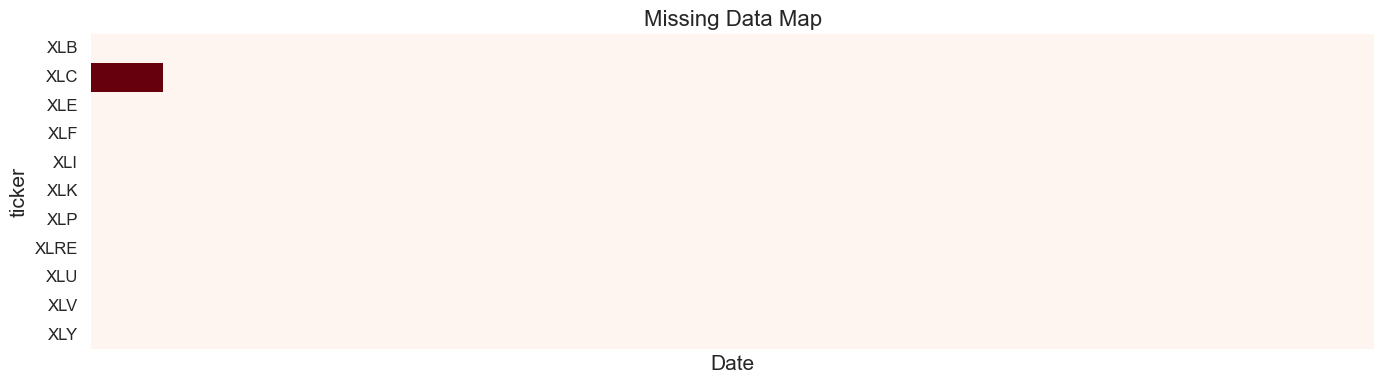

In [ ]:
fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(
    prices.isnull().T,
    cbar=False,
    ax=ax,
    yticklabels=True,
    xticklabels=False,
    cmap="Reds"
)
ax.set_title("Missing Data Map")
ax.set_xlabel("Date")
plt.tight_layout()
plt.savefig("../figures/missing_data_map.png", dpi=150, bbox_inches="tight")
plt.show()

In [45]:
# Trim to first date where all sectors have data
first_valid = prices.dropna().index.min()
prices = prices.loc[first_valid:]

print(f"\nTrimmed start date: {first_valid.date()}")
print(f"Trimmed shape:      {prices.shape}")
print(f"Nulls remaining:    {prices.isnull().sum().sum()}")


Trimmed start date: 2018-06-19
Trimmed shape:      (1956, 11)
Nulls remaining:    0


## Raw price history

Check that data was downloaded and processed correctly.

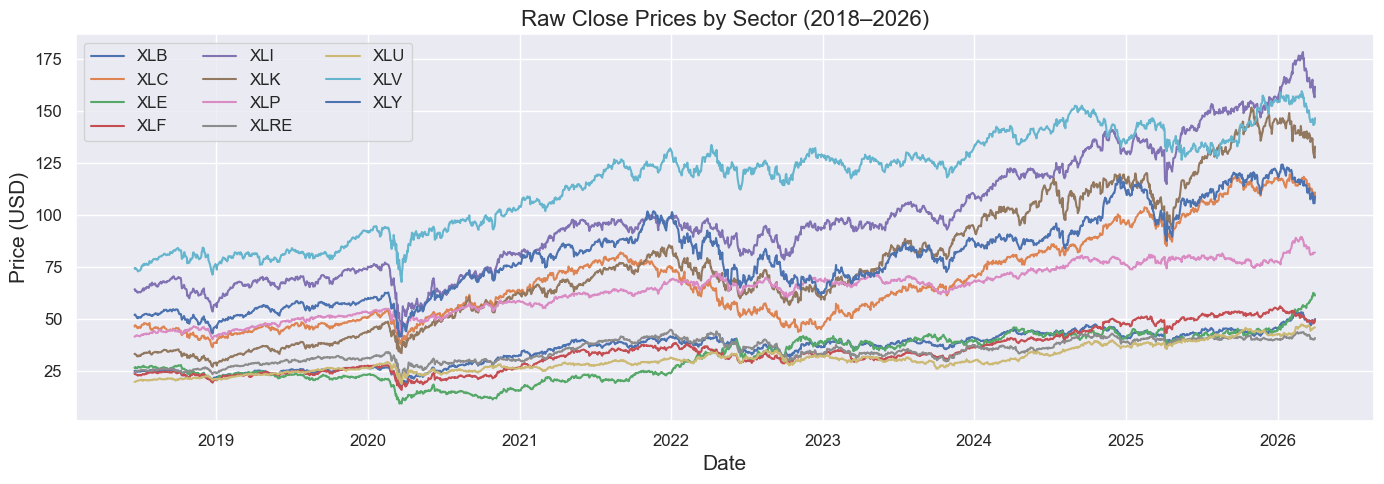

In [50]:
fig, ax = plt.subplots()
for ticker in prices.columns:
    ax.plot(prices.index, prices[ticker], linewidth=1.5, label=ticker)

ax.set_title("Raw Close Prices by Sector (2018–2026)")
ax.set_ylabel("Price (USD)")
ax.set_xlabel("Date")
ax.legend(loc="upper left", fontsize=12, ncol=3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator())
plt.tight_layout()
plt.show()

## Normalized Performance

Every sector is rebased to 100 at the start date. This removes the price-level distortion from the raw chart and lets us directly compare growth rates. The value tells us about the cumulative return.

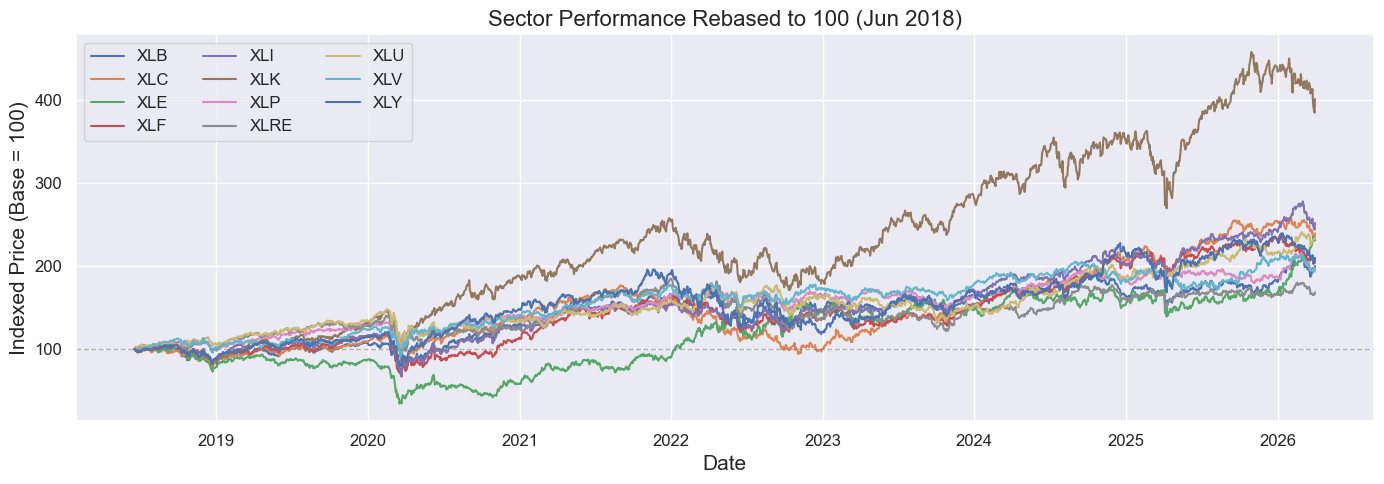

In [53]:
rebased = (prices / prices.iloc[0]) * 100

fig, ax = plt.subplots()
for ticker in prices.columns:
    ax.plot(rebased.index, rebased[ticker], linewidth=1.5, label=ticker)

ax.axhline(100, color="gray", linewidth=1, linestyle="--", alpha=0.6)
ax.set_title("Sector Performance Rebased to 100 (Jun 2018)")
ax.set_ylabel("Indexed Price (Base = 100)")
ax.set_xlabel("Date")
ax.legend(loc="upper left", fontsize=12, ncol=3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator())

plt.tight_layout()
plt.show()

Notes:

- XLK, particularly after 2020, is well ahead of the other sectors.
- XLE is the most volatile as it is below 100 from roughly 2019 - 2022. Something happened here for it exploded around 2022.

## Daily Returns

Day-over-day percentage change in price. The COVID crash (March 2020) and the rate hike volatility (2022) are seen visibly as spikes. This shows what is known as volatility clustering or calm periods where all lines stay near zero punctuated by sudden burst of large swings.

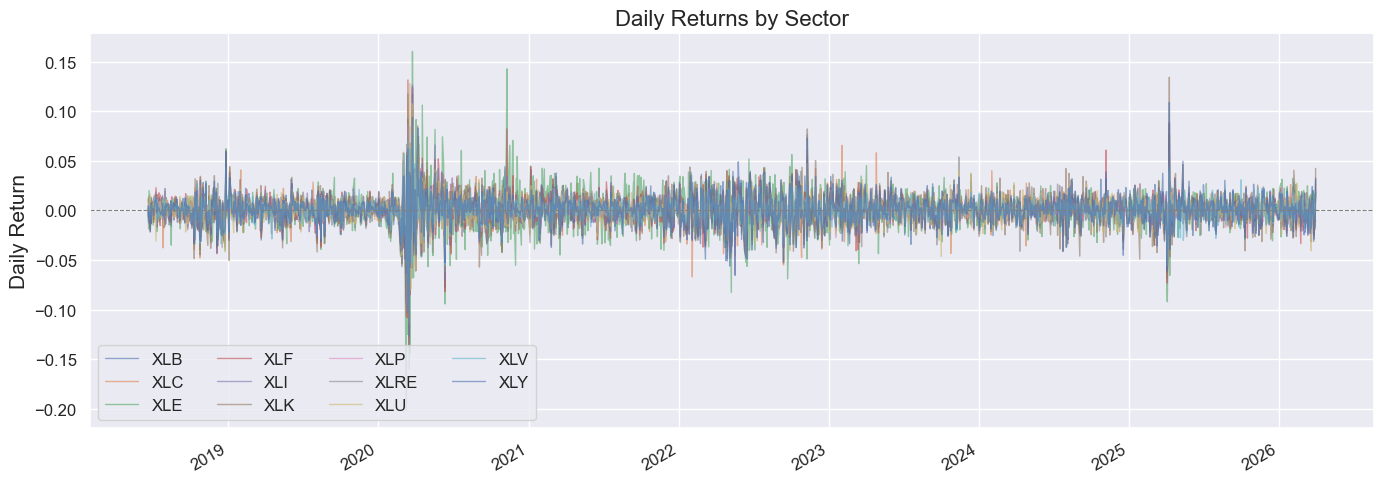

In [ ]:
# computes (today - yesterday) / yesterday for each sector to get daily returns
returns = prices.pct_change().dropna()

fig, ax = plt.subplots()
returns.plot(ax=ax, linewidth=1.0, alpha=0.6)
ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
ax.set_title("Daily Returns by Sector")
ax.set_ylabel("Daily Return")
ax.set_xlabel("")
ax.legend(loc="lower left", fontsize=12, ncol=4)
plt.tight_layout()
plt.show()

## Return distribution per sector

Histograms of daily returns per sector. Returns are assumed to be normally distributed, but they are not. A narrow, tall distribution means stable, predictable returns. A wide, flat distribution means high volatility and fat tails. In general, extreme days happen more often than a normal distribution would predict.

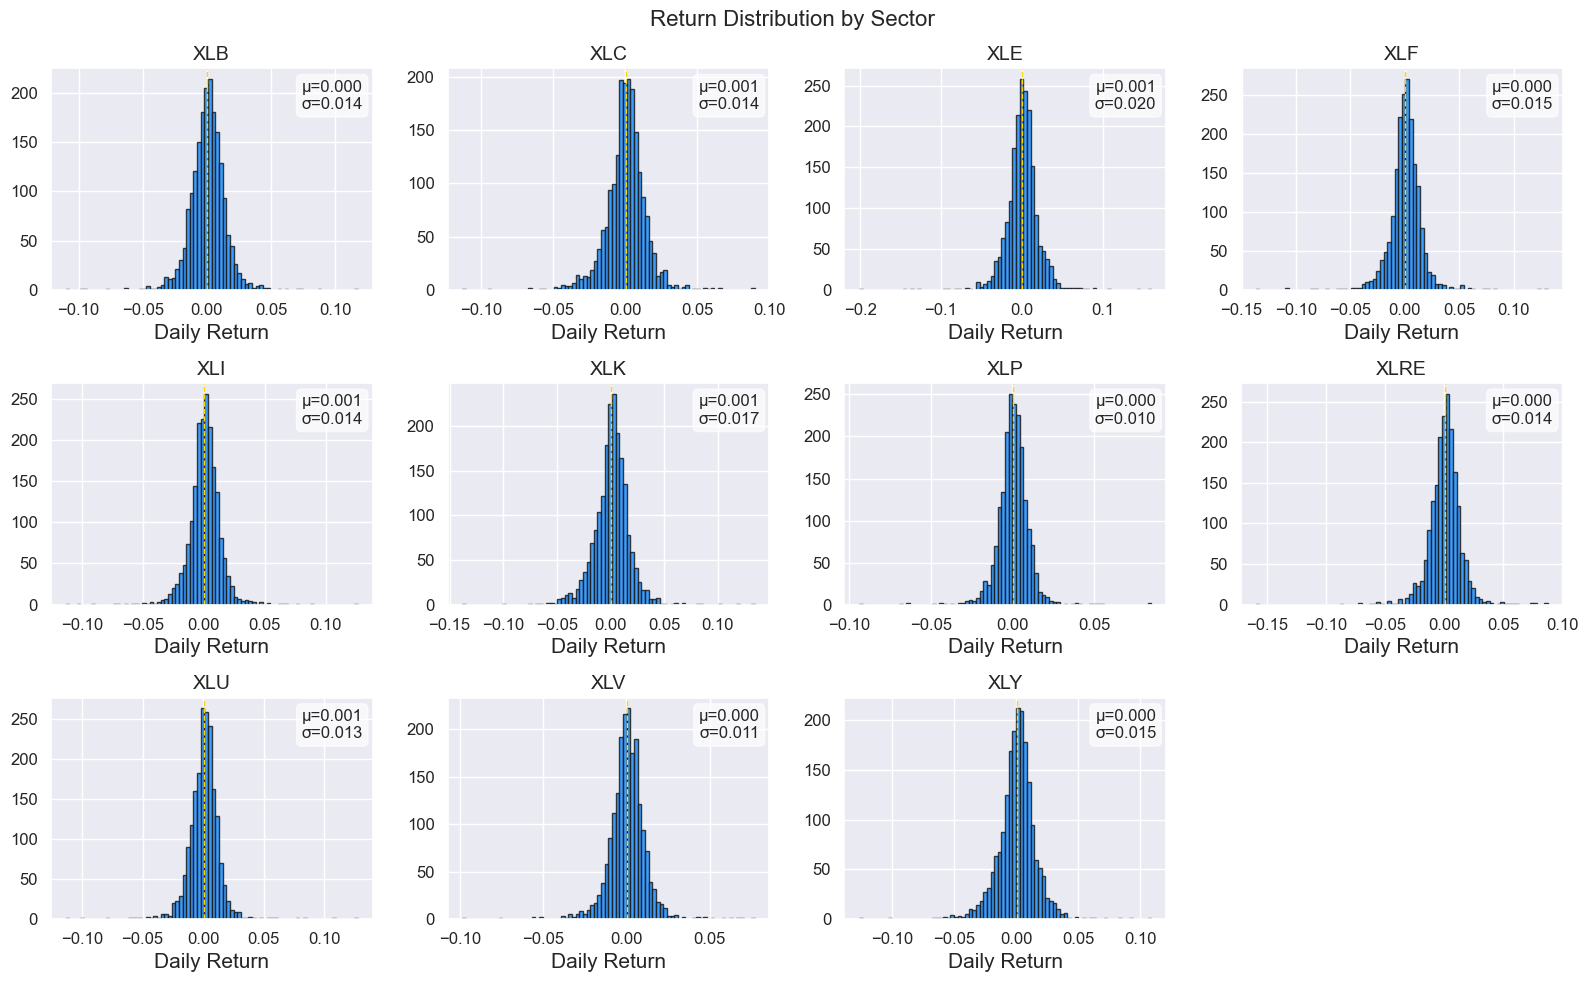

In [60]:
fig, axes = plt.subplots(3, 4, figsize=(16, 10), sharey=False)
axes = axes.flatten()

for i, ticker in enumerate(sorted(returns.columns)):
    r = returns[ticker].dropna()
    axes[i].hist(r, bins=80, color="dodgerblue", edgecolor="k", alpha=0.85)
    axes[i].axvline(r.mean(), color="gold", linewidth=1, linestyle="--")
    axes[i].set_title(ticker, fontsize=14)
    axes[i].set_xlabel("Daily Return")
    axes[i].annotate(
        f"μ={r.mean():.3f}\nσ={r.std():.3f}",
        xy=(0.97, 0.95), xycoords="axes fraction",
        ha="right", va="top", fontsize=12,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7)
    )

axes[-1].set_visible(False)
plt.suptitle("Return Distribution by Sector", fontsize=16)
plt.tight_layout()
plt.show()

Notes:

- All sectors show roughly zero mean, so daily returns are tiny compared to annual returns.
- Sigma should be the volatility predicter. XLE has the greatest volatility while XLP and XLV are among the least volatile.

## Annualized volatility

Daily volatility (sigma) scaled to annual by multiplying by sqrt(252). The scaling factor is because there are roughly 252 trading days in a year.

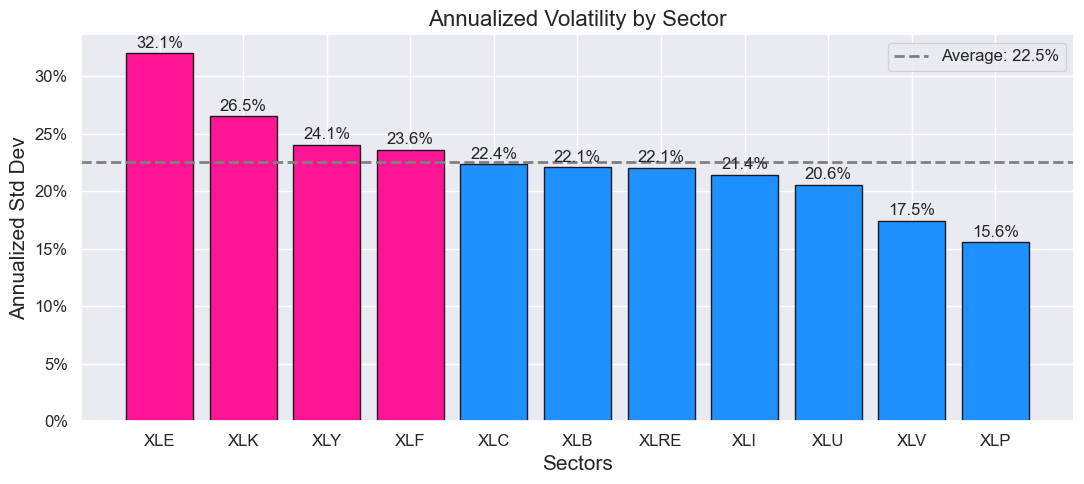

In [66]:
volatility = (returns.std() * (252 ** 0.5)).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(11, 5))
colors = ["deeppink" if v > volatility.mean() else "dodgerblue" for v in volatility]
bars = ax.bar(volatility.index, volatility.values, color=colors, edgecolor="k")
ax.axhline(
    volatility.mean(), color="gray", linewidth=2,
    linestyle="--", label=f"Average: {volatility.mean():.1%}"
)
ax.set_title("Annualized Volatility by Sector")
ax.set_ylabel("Annualized Std Dev")
ax.set_xlabel("Sectors")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.legend(fontsize=12)

# Value labels on top of each bar
for bar, val in zip(bars, volatility.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.002,
        f"{val:.1%}", ha="center", va="bottom", fontsize=12
    )

plt.tight_layout()
plt.show()

Notes:

- XLE is very volatile. It is oil so it makes sense given everything that has happened in this period.
- XLP and XLV are the least volatile. Not that strongly affected by the events.
- The average is around 22.5%. So, the sectors above it have more above market risk while those below are where capital tends to flow during risky periods.

## Rolling 90-day volatility

Because the bar chart collapses 8 years into a single number per sector, it hides when the volatility happens. We can visualize the rolling volatility by using a sliding window of 90 days. This will tells us how risk evovled over time rather than treating the whole period as homogeneous.

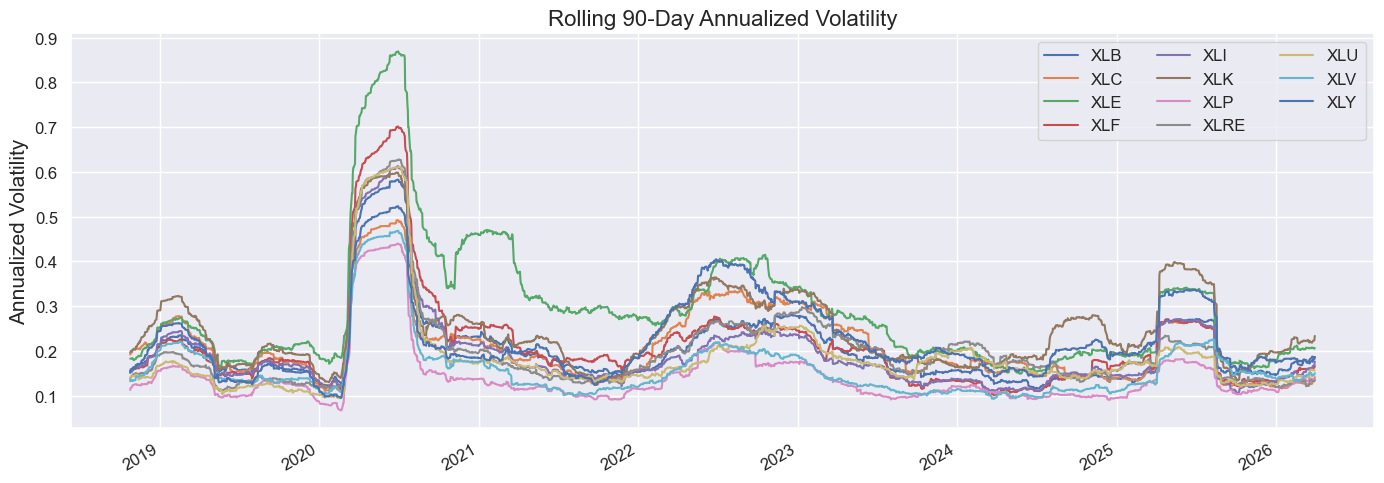

In [67]:
rolling_vol = returns.rolling(90).std() * (252 ** 0.5)

fig, ax = plt.subplots()
rolling_vol.plot(ax=ax, linewidth=1.5)
ax.set_title("Rolling 90-Day Annualized Volatility")
ax.set_ylabel("Annualized Volatility")
ax.set_xlabel("")
ax.legend(loc="upper right", fontsize=12, ncol=3)
plt.tight_layout()
plt.show()

Notes:

- Large spikes can be seen around 2020.5, 2021, and 2025.5.
- Around 2020.5, all the sectors spike sharply at the same time while they decrease except for XLE in 2021.
- There is another sudden spike around 2025.5 as well for all sectors but not as strong as the one in 2020.5.

##  Correlation heatmap

Pearson correlation of daily returns across all sector pairs. Values close  to 1.0 mean the two sectors move together (i.e., low diversification benefit.) Values closer to 0 mean they move independently.

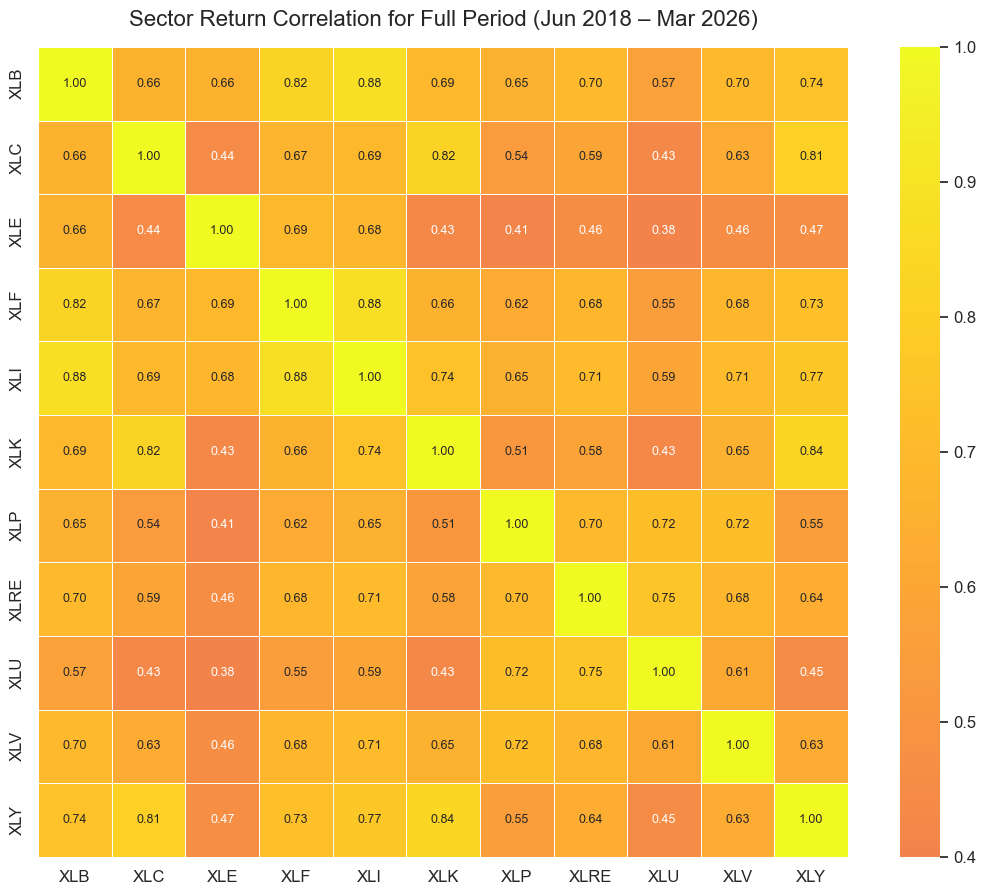

5 least correlated pairs:
ticker  ticker
XLE     XLU       0.38
        XLP       0.41
XLC     XLU       0.43
XLE     XLK       0.43
XLK     XLU       0.43
dtype: float64

5 most correlated pairs:
ticker  ticker
XLY     XLP      NaN
        XLRE     NaN
        XLU      NaN
        XLV      NaN
        XLY      NaN
dtype: float64


In [77]:
corr = returns.corr().round(2)

fig, ax = plt.subplots(figsize=(11, 9))
mask = pd.DataFrame(False, index=corr.index, columns=corr.columns)

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="plasma",
    center=0,
    vmin=0.4,
    vmax=1.0,
    linewidths=0.5,
    square=True,
    ax=ax,
    annot_kws={"size": 9}
)
ax.set_title("Sector Return Correlation for Full Period (Jun 2018 – Mar 2026)", pad=15)
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

pairs = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
pairs = pairs.stack().sort_values()
print("5 least correlated pairs:")
print(pairs.head())
print("\n5 most correlated pairs:")
print(pairs.tail())

## Market cycle breakdown

The full period contains distinct macro environments. Rebasing each window to 100 at its own start date shows which sectors led and lagged in each regime, so not cumulatively from 2018, but within that specific environment. 

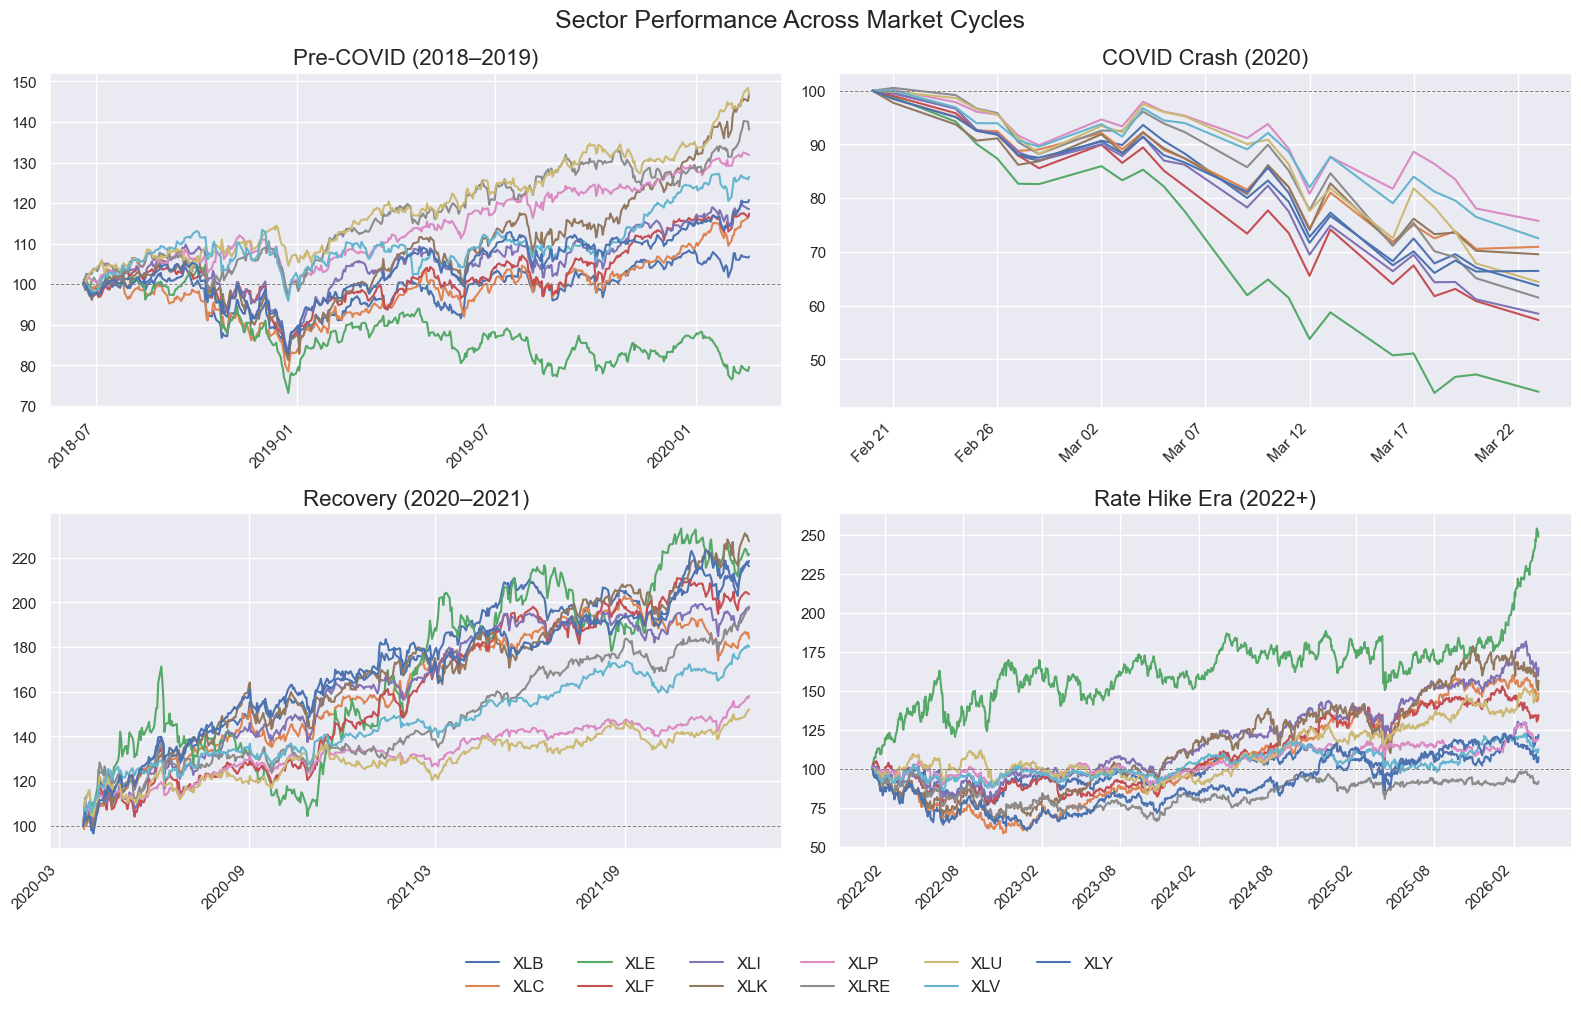

In [33]:
cycles = {
    "Pre-COVID (2018–2019)": ("2018-01-01", "2020-02-19"),
    "COVID Crash (2020)":    ("2020-02-20", "2020-03-23"),
    "Recovery (2020–2021)":  ("2020-03-24", "2021-12-31"),
    "Rate Hike Era (2022+)": ("2022-01-01", "2026-04-01"),
}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, (label, (start, end)) in enumerate(cycles.items()):
    subset = prices.loc[start:end]
    rebased_cycle = (subset / subset.iloc[0]) * 100

    # Convert index to datetime so matplotlib controls it, not pandas
    rebased_cycle.index = pd.to_datetime(rebased_cycle.index)

    ax = axes[i]
    for col in rebased_cycle.columns:
        ax.plot(rebased_cycle.index, rebased_cycle[col], linewidth=1.5)

    ax.axhline(100, color="gray", linewidth=0.7, linestyle="--")
    ax.set_title(label)
    ax.set_xlabel("")

    days = (pd.Timestamp(end) - pd.Timestamp(start)).days

    if days < 60:
        ax.xaxis.set_major_locator(mdates.DayLocator(interval=5))
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    elif days < 400:
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    else:
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right")

handles = [plt.Line2D([0], [0], color=f"C{j}", linewidth=1.5) 
           for j in range(len(rebased_cycle.columns))]
labels = list(rebased_cycle.columns)

fig.legend(
    handles, labels,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.02),
    ncol=6,
    fontsize=12,
    frameon=False
)

plt.suptitle("Sector Performance Across Market Cycles", fontsize=18)
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()


## Ranked Returns Per Cycle

Total return from the start to the end of each market cycle, ranked best to worst. 

In [78]:
print("=" * 45)
for label, (start, end) in cycles.items():
    subset = prices.loc[start:end]
    total_return = (subset.iloc[-1] / subset.iloc[0] - 1).sort_values(ascending=False)

    print(f"\n{label}")
    print("-" * 35)
    for ticker, val in total_return.items():
        bar = "█" * int(abs(val) * 20)
        sign = "+" if val >= 0 else ""
        name = SECTOR_NAMES.get(ticker, ticker)
        print(f"  {ticker:<5} {name:<20} {sign}{val:.1%}  {bar}")
print("\n" + "=" * 45)


Pre-COVID (2018–2019)
-----------------------------------
  XLK   Technology           +46.9%  █████████
  XLU   Utilities            +46.8%  █████████
  XLRE  Real Estate          +38.1%  ███████
  XLP   Consumer Staples     +31.9%  ██████
  XLV   Health Care          +26.5%  █████
  XLY   Consumer Discr.      +20.8%  ████
  XLI   Industrials          +18.5%  ███
  XLF   Financials           +17.4%  ███
  XLC   Communication        +16.9%  ███
  XLB   Materials            +6.8%  █
  XLE   Energy               -20.4%  ████

COVID Crash (2020)
-----------------------------------
  XLP   Consumer Staples     -24.2%  ████
  XLV   Health Care          -27.5%  █████
  XLC   Communication        -29.1%  █████
  XLK   Technology           -30.4%  ██████
  XLY   Consumer Discr.      -33.5%  ██████
  XLU   Utilities            -35.6%  ███████
  XLB   Materials            -36.3%  ███████
  XLRE  Real Estate          -38.5%  ███████
  XLI   Industrials          -41.5%  ████████
  XLF   Financial

## Key Takeaways

**1. Sector leadership rotates with the macro regime.** There is no sector that wins in every environment. XLK dominated the recovery but lagged in the rate hike era. XLE was a disaster pre-COVID and the best performer afterward.

**2. Correlation goes to 1 in a crash.** The heatmap shows average correlations of 0.7-0.9 across the full period. In March 2020 that number was closer to 1 for most pairs. Sector diversification smooths returns in normal markets but provides almost no protection in a systemic shock.

**3. Volatility is not constant because it clusters.** The rolling volatility chart makes this obvious. The COVID spike and the 2022 elevation are structurally different: one was a sudden shock, the other was a sustained repricing.

**4. Defensive sectors make a real tradeoff.** XLP and XLV consistently sit near the bottom of the return rankings in bull markets and near the top in bear markets.

**5. XLE is an outlier in every dimension.** Highest volatility, widest return range, lowest correlation with tech.